In [1]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

!pip install ipython-sql==0.5.0 prettytable==3.9.0

%load_ext sql
%config SqlMagic.style = 'PLAIN_COLUMNS'
%sql sqlite:///shop.db

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 103.8 MB/s eta 0:00:00
  Attempting uninstall: prettytable
    Found existing installation: prettytable 3.18.0
    Uninstalling prettytable-3.18.0:
      Successfully uninstalled prettytable-3.18.0


In [2]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"
response = requests.get(url)
data = response.json()
print(data)

{'total_count': 1242776, 'incomplete_results': False, 'items': [{'id': 45717250, 'node_id': 'MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==', 'name': 'tensorflow', 'full_name': 'tensorflow/tensorflow', 'private': False, 'owner': {'login': 'tensorflow', 'id': 15658638, 'node_id': 'MDEyOk9yZ2FuaXphdGlvbjE1NjU4NjM4', 'avatar_url': 'https://avatars.githubusercontent.com/u/15658638?v=4', 'gravatar_id': '', 'url': 'https://api.github.com/users/tensorflow', 'html_url': 'https://github.com/tensorflow', 'followers_url': 'https://api.github.com/users/tensorflow/followers', 'following_url': 'https://api.github.com/users/tensorflow/following{/other_user}', 'gists_url': 'https://api.github.com/users/tensorflow/gists{/gist_id}', 'starred_url': 'https://api.github.com/users/tensorflow/starred{/owner}{/repo}', 'subscriptions_url': 'https://api.github.com/users/tensorflow/subscriptions', 'organizations_url': 'https://api.github.com/users/tensorflow/orgs', 'repos_url': 'https://api.github.com/users/tensorflow/repos',

In [3]:
print(response.status_code)

200


In [4]:
repositories = data["items"]
df = pd.DataFrame(repositories)

print(df.head())

          id                           node_id                      name  \
0   45717250  MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==                tensorflow   
1  155220641  MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=              transformers   
2  343965132  MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=          ML-For-Beginners   
3  145553672  MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=                    funNLP   
4   21872392  MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==  awesome-machine-learning   

                               full_name  private  \
0                  tensorflow/tensorflow    False   
1               huggingface/transformers    False   
2             microsoft/ML-For-Beginners    False   
3                  fighting41love/funNLP    False   
4  josephmisiti/awesome-machine-learning    False   

                                               owner  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...   
1  {'login': 'huggingface', 'id': 25720743, 'node...   
2  {'login': 'microsoft', 'id': 6154722, 'node_id...   


In [5]:
repositories = data["items"]
df = pd.DataFrame(repositories)
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76183,2967,198017,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34386,2402,164613,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,22116,13,89903,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15277,52,82754,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15638,30,74210,master,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [7]:
df.shape

(100, 82)

In [8]:
df.columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [9]:
df = df[
    [
        "name",
        "owner",
        "language",
        "stargazers_count",
        "forks_count",
        "watchers_count",
        "open_issues_count",
        "created_at",
        "updated_at",
        "license"
    ]
]

df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,198017,76183,198017,2967,2015-11-07T01:19:20Z,2026-08-29T22:29:07Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164613,34386,164613,2402,2018-10-29T13:56:00Z,2026-08-29T22:31:28Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89903,22116,89903,13,2021-03-03T01:34:05Z,2026-08-29T22:32:44Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82754,15277,82754,52,2018-08-21T11:20:39Z,2026-08-29T20:20:31Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74210,15638,74210,30,2014-07-15T19:11:19Z,2026-08-29T20:19:42Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


In [10]:
print(df.columns)

Index(['name', 'owner', 'language', 'stargazers_count', 'forks_count',
       'watchers_count', 'open_issues_count', 'created_at', 'updated_at',
       'license'],
      dtype='object')


In [11]:
df["owner"] = df["owner"].apply(lambda x: x.get("login") if isinstance(x, dict) else None)
df["license"] = df["license"].apply(lambda x: x.get("name") if isinstance(x, dict) else None)
print(df.head())

                       name           owner          language  \
0                tensorflow      tensorflow               C++   
1              transformers     huggingface            Python   
2          ML-For-Beginners       microsoft  Jupyter Notebook   
3                    funNLP  fighting41love            Python   
4  awesome-machine-learning    josephmisiti            Python   

   stargazers_count  forks_count  watchers_count  open_issues_count  \
0            198017        76183          198017               2967   
1            164613        34386          164613               2402   
2             89903        22116           89903                 13   
3             82754        15277           82754                 52   
4             74210        15638           74210                 30   

             created_at            updated_at             license  
0  2015-11-07T01:19:20Z  2026-08-29T22:29:07Z  Apache License 2.0  
1  2018-10-29T13:56:00Z  2026-08-29T22:31:28Z 

In [12]:
print(df.isnull().sum())

name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license              22
dtype: int64


In [13]:
df["language"] = df["language"].fillna("Unknown")
df["license"] = df["license"].fillna("Unknown")

In [14]:
print(df.isnull().sum())

name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.dtypes

,0
name,object
owner,object
language,object
stargazers_count,int64
forks_count,int64
watchers_count,int64
open_issues_count,int64
created_at,object
updated_at,object
license,object


In [19]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [20]:
df.dtypes

,0
name,object
owner,object
language,object
stargazers_count,int64
forks_count,int64
watchers_count,int64
open_issues_count,int64
created_at,"datetime64[ns, UTC]"
updated_at,"datetime64[ns, UTC]"
license,object


In [21]:
df = df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
    })
df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,198017,76183,198017,2967,2015-11-07 01:19:20+00:00,2026-08-29 22:29:07+00:00,Apache License 2.0
1,transformers,huggingface,Python,164613,34386,164613,2402,2018-10-29 13:56:00+00:00,2026-08-29 22:31:28+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89903,22116,89903,13,2021-03-03 01:34:05+00:00,2026-08-29 22:32:44+00:00,MIT License
3,funNLP,fighting41love,Python,82754,15277,82754,52,2018-08-21 11:20:39+00:00,2026-08-29 20:20:31+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74210,15638,74210,30,2014-07-15 19:11:19+00:00,2026-08-29 20:19:42+00:00,Other


In [22]:
print(df.dtypes)

name                         object
owner                        object
language                     object
stars                         int64
forks                         int64
watchers                      int64
open_issues                   int64
created_date    datetime64[ns, UTC]
updated_date    datetime64[ns, UTC]
license                      object
dtype: object


In [23]:
df.to_csv("github_projects.csv", index=False)

In [24]:
df_check = pd.read_csv("github_projects.csv")

In [25]:
df_check.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,198017,76183,198017,2967,2015-11-07 01:19:20+00:00,2026-08-29 22:29:07+00:00,Apache License 2.0
1,transformers,huggingface,Python,164613,34386,164613,2402,2018-10-29 13:56:00+00:00,2026-08-29 22:31:28+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89903,22116,89903,13,2021-03-03 01:34:05+00:00,2026-08-29 22:32:44+00:00,MIT License
3,funNLP,fighting41love,Python,82754,15277,82754,52,2018-08-21 11:20:39+00:00,2026-08-29 20:20:31+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74210,15638,74210,30,2014-07-15 19:11:19+00:00,2026-08-29 20:19:42+00:00,Other


In [26]:
df_check.shape

(100, 10)

In [27]:
df_check.columns

Index(['name', 'owner', 'language', 'stars', 'forks', 'watchers',
       'open_issues', 'created_date', 'updated_date', 'license'],
      dtype='object')

In [28]:
df_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          100 non-null    object
 1   owner         100 non-null    object
 2   language      100 non-null    object
 3   stars         100 non-null    int64 
 4   forks         100 non-null    int64 
 5   watchers      100 non-null    int64 
 6   open_issues   100 non-null    int64 
 7   created_date  100 non-null    object
 8   updated_date  100 non-null    object
 9   license       100 non-null    object
dtypes: int64(4), object(6)
memory usage: 7.9+ KB


In [29]:
df = pd.read_csv("github_projects.csv")
connection = sqlite3.connect("github_projects.db")
df.to_sql("Repositories", connection, if_exists="replace", index=False)

100

In [30]:
query = """
SELECT *
FROM Repositories
WHERE stars > 10000;
"""

result = pd.read_sql(query, connection)

print(result)

                               name           owner          language   stars  \
0                        tensorflow      tensorflow               C++  198017   
1                      transformers     huggingface            Python  164613   
2                  ML-For-Beginners       microsoft  Jupyter Notebook   89903   
3                            funNLP  fighting41love            Python   82754   
4          awesome-machine-learning    josephmisiti            Python   74210   
..                              ...             ...               ...     ...   
65  machine-learning-systems-design       chiphuyen              HTML   10563   
66                 Machine-Learning    Jack-Cherish            Python   10377   
67           machine-learning-notes      roboticcam  Jupyter Notebook   10346   
68              3D-Machine-Learning     timzhang642           Unknown   10195   
69                             tpot    EpistasisLab  Jupyter Notebook   10051   

    forks  watchers  open_i

In [31]:
query = """
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%';
"""

result = pd.read_sql(query, connection)

print(result)

                                                 name  \
0                            awesome-machine-learning   
1   500-AI-Machine-learning-Deep-learning-Computer...   
2             machine-learning-for-software-engineers   
3                           homemade-machine-learning   
4                 awesome-production-machine-learning   
5                        machine-learning-for-trading   
6                    stanford-cs-229-machine-learning   
7                          Machine-Learning-Tutorials   
8                           machine-learning-zoomcamp   
9                          machine-learning-interview   
10                       python-machine-learning-book   
11                         dive-into-machine-learning   
12                    machine-learning-systems-design   
13                                   Machine-Learning   
14                             machine-learning-notes   
15                                3D-Machine-Learning   
16                             

In [32]:
query1 = """
SELECT name, stars, forks
FROM Repositories
WHERE stars > 10000
AND forks > 1000;
"""

result1 = pd.read_sql(query1, connection)

print("Repositories with more than 10,000 stars AND 1,000 forks:")
print(result1)

Repositories with more than 10,000 stars AND 1,000 forks:
                               name   stars  forks
0                        tensorflow  198017  76183
1                      transformers  164613  34386
2                  ML-For-Beginners   89903  22116
3                            funNLP   82754  15277
4          awesome-machine-learning   74210  15638
..                              ...     ...    ...
64  machine-learning-systems-design   10563   1634
65                 Machine-Learning   10377   5064
66           machine-learning-notes   10346   1826
67              3D-Machine-Learning   10195   1798
68                             tpot   10051   1562

[69 rows x 3 columns]


In [33]:
query2 = """
SELECT name, stars, forks
FROM Repositories
WHERE stars > 20000
OR forks > 5000;
"""

result2 = pd.read_sql(query2, connection)

print("\nRepositories with more than 20,000 stars OR 5,000 forks:")
print(result2)


Repositories with more than 20,000 stars OR 5,000 forks:
                                                 name   stars  forks
0                                          tensorflow  198017  76183
1                                        transformers  164613  34386
2                                    ML-For-Beginners   89903  22116
3                                              funNLP   82754  15277
4                            awesome-machine-learning   74210  15638
5                                        scikit-learn   67096  27333
6                                              gradio   43438   3581
7   500-AI-Machine-learning-Deep-learning-Computer...   36623   7475
8                                         C-Plus-Plus   34622   7853
9                                              netron   33425   3175
10                                    ML-From-Scratch   32546   5433
11                                         applied-ml   30097   3992
12            machine-learning-for-software-e

In [34]:
query3 = """
SELECT name, language
FROM Repositories
WHERE NOT language = 'Python';
"""

result3 = pd.read_sql(query3, connection)

print("\nRepositories that do NOT use Python:")
print(result3)


Repositories that do NOT use Python:
                                                 name          language
0                                          tensorflow               C++
1                                    ML-For-Beginners  Jupyter Notebook
2   500-AI-Machine-learning-Deep-learning-Computer...           Unknown
3                                         C-Plus-Plus               C++
4                                              netron        JavaScript
..                                                ...               ...
65                    Machine-learning-learning-notes           Unknown
66                                  awesome-youtubers          Markdown
67                 Learn_Machine_Learning_in_3_Months           Unknown
68                                              h2o-3  Jupyter Notebook
69                          industry-machine-learning  Jupyter Notebook

[70 rows x 2 columns]


In [35]:
query = """
SELECT name, owner, language, stars, forks
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

result = pd.read_sql(query, connection)

print("Top 10 repositories by stars:")
print(result)

Top 10 repositories by stars:
                                                name           owner  \
0                                         tensorflow      tensorflow   
1                                       transformers     huggingface   
2                                   ML-For-Beginners       microsoft   
3                                             funNLP  fighting41love   
4                           awesome-machine-learning    josephmisiti   
5                                       scikit-learn    scikit-learn   
6                                             gradio      gradio-app   
7  500-AI-Machine-learning-Deep-learning-Computer...   ashishpatel26   
8                                        C-Plus-Plus   TheAlgorithms   
9                                             netron      lutzroeder   

           language   stars  forks  
0               C++  198017  76183  
1            Python  164613  34386  
2  Jupyter Notebook   89903  22116  
3            Python   82754  

In [43]:
query = """
SELECT name, owner, language, stars, forks
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

result = pd.read_sql(query, connection)

print("Top 10 repositories by stars:")
print(result)

 * sqlite:///shop.db
(sqlite3.OperationalError) no such table: Repositories
[SQL: SELECT
    name,
    owner,
    language,
    stars,
    forks
FROM Repositories
ORDER BY stars DESC
LIMIT 10;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [37]:
query1 = """
SELECT COUNT(*) AS total_repositories
FROM Repositories;
"""

result1 = pd.read_sql(query1, connection)
print(result1)

   total_repositories
0                 100


In [38]:
query2 = """
SELECT AVG(stars) AS average_stars
FROM Repositories;
"""

result2 = pd.read_sql(query2, connection)
print(result2)

   average_stars
0       20855.92


In [39]:
query = """
SELECT
    language,
    COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;
"""

result = pd.read_sql(query, connection)

print(result)

           language  repository_count
0            Python                30
1           Unknown                23
2  Jupyter Notebook                19
3               C++                12


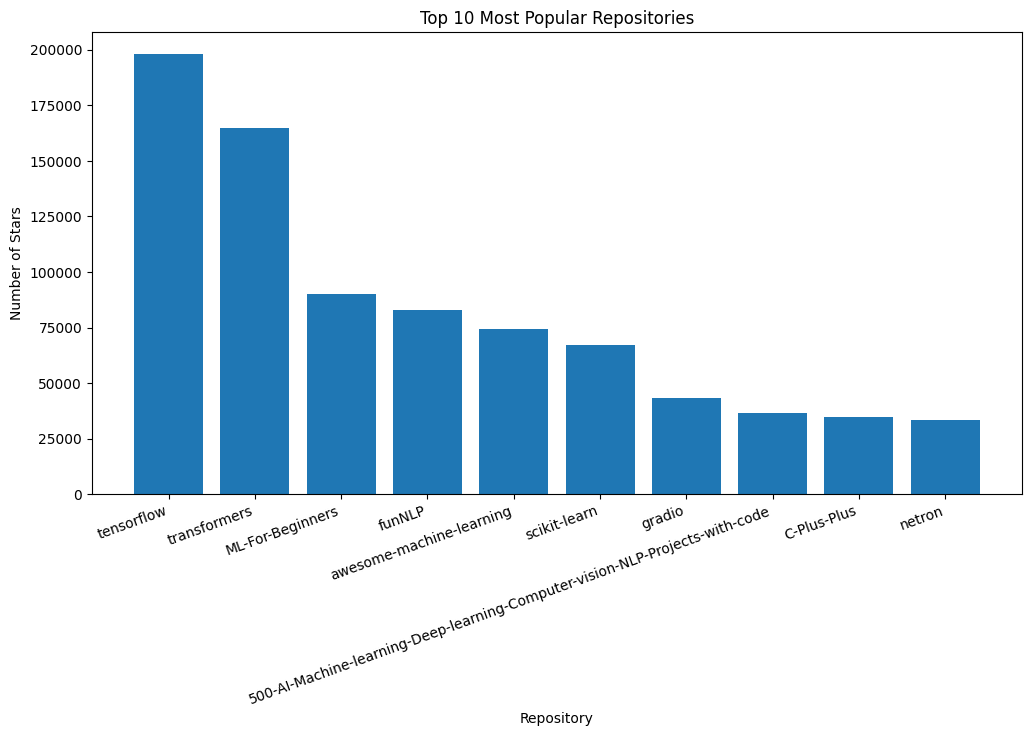

In [40]:
query = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

top_repositories = pd.read_sql(query, connection)

plt.figure(figsize=(12, 6))

plt.bar(top_repositories["name"], top_repositories["stars"])

plt.xlabel("Repository")
plt.ylabel("Number of Stars")
plt.title("Top 10 Most Popular Repositories")

plt.xticks(rotation=20, ha="right")

plt.show()

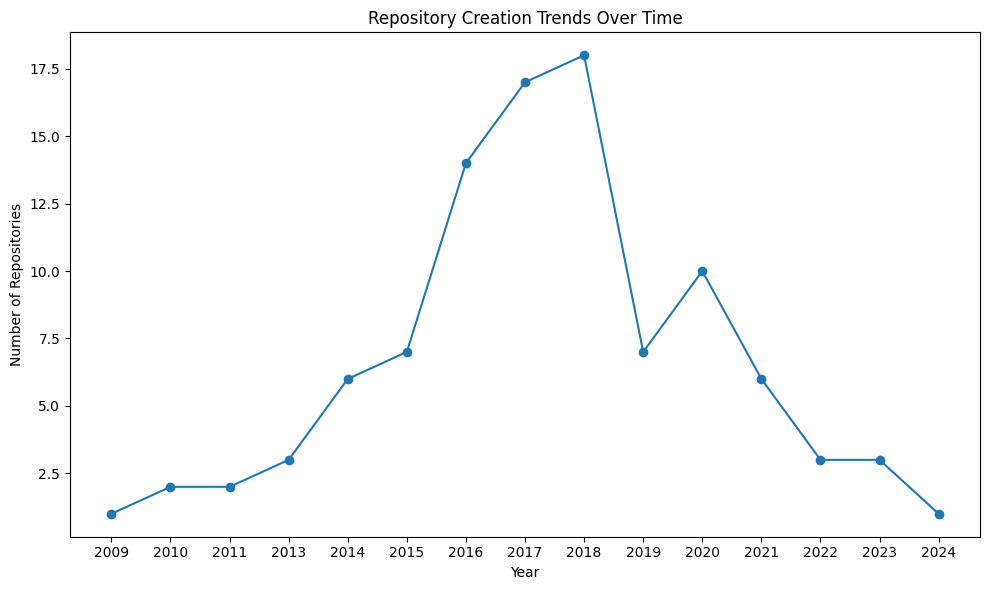

In [41]:
query = """
SELECT
    strftime('%Y', created_date) AS year,
    COUNT(*) AS repository_count
FROM Repositories
GROUP BY year
ORDER BY year;
"""

creation_trends = pd.read_sql(query, connection)

plt.figure(figsize=(10, 6))

plt.plot(
    creation_trends["year"],
    creation_trends["repository_count"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.title("Repository Creation Trends Over Time")

plt.tight_layout()

plt.show()

Most popular repostry: tensorflow

Least popular repository: netron


Biggest number of repositories made in a year: 2018

Smallest number of repository made in a year: 2009

1. Why is it important to verify data collected from public APIs?

It is important to verify data from public APIs because the data may contain missing, outdated, duplicated, or inaccurate information. Checking the data helps ensure that the analysis is based on reliable information and reduces the chance of producing incorrect conclusions.

2. Why should data analysts document the source of their data?

Data analysts should document the source so that others can understand where the data came from and how it was collected. This makes the analysis more transparent and reproducible. In this project, the data was collected from the GitHub API, so documenting the source allows others to understand the origin of the repository information.

3. How can missing or inaccurate data affect data analysis and decision-making?

Missing or inaccurate data can lead to incorrect calculations, misleading patterns, and unreliable conclusions. For example, missing programming-language information could affect an analysis of which languages are most common. If the data is inaccurate, decisions based on the analysis may also be incorrect. Therefore, data should be cleaned, checked, and verified before using it for decision-making.

GitHub Repository:
https://github.com/Andrea2431A/github-ml-analysis